<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula13a_isolation_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X.shape: (1000, 2)
y.shape: (1000,)


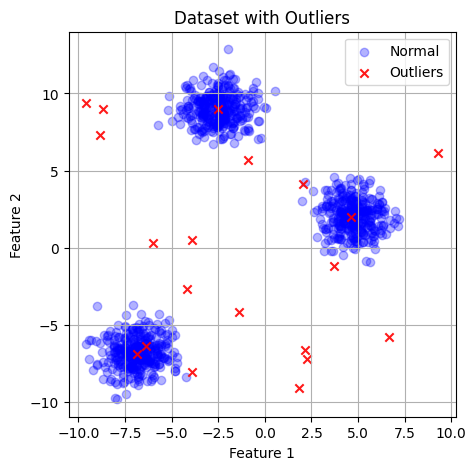

In [10]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

n_samples = 980
n_features = 2
n_centers = 3
random_state = 42

X_normal, y_normal = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_centers, random_state=random_state)
y_normal[:] = 1

n_outliers = 20
rng = np.random.RandomState(random_state)
outliers = rng.uniform(low=-10, high=10, size=(n_outliers, n_features))

X = np.concatenate([X_normal, outliers])
y = np.concatenate([y_normal, -np.ones(n_outliers)])

print(f"X.shape: {X.shape}")
print(f"y.shape: {y.shape}")

plt.figure(figsize=(5, 5))
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='blue', marker='o', label='Normal', alpha=0.3)
plt.scatter(outliers[:, 0], outliers[:, 1], c='red', marker='x', label='Outliers', alpha=0.9)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset with Outliers')
plt.legend()
plt.grid()
plt.show()

In [11]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

model = IsolationForest(random_state=random_state)
model.fit(X)

y_pred = model.predict(X)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

        -1.0       0.06      0.80      0.12        20
         1.0       0.99      0.76      0.86       980

    accuracy                           0.76      1000
   macro avg       0.53      0.78      0.49      1000
weighted avg       0.98      0.76      0.85      1000



              precision    recall  f1-score   support

        -1.0       0.06      0.80      0.12        20
         1.0       0.99      0.76      0.86       980

    accuracy                           0.76      1000
   macro avg       0.53      0.78      0.49      1000
weighted avg       0.98      0.76      0.85      1000



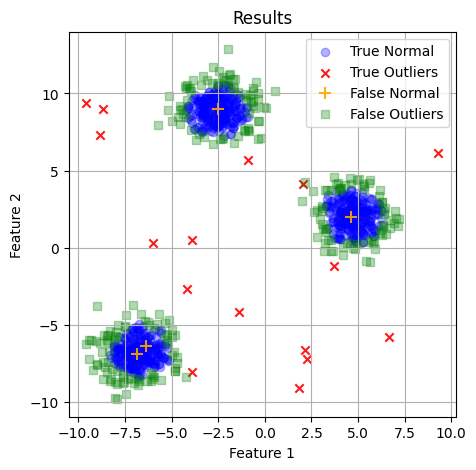

In [14]:
def plot_results(X, y, labels):
    true_normal = X[np.logical_and((y == 1), (labels == 1))]
    true_outliers = X[np.logical_and((y == -1), (labels == -1))]
    false_normal = X[np.logical_and((y == -1), (labels == 1))]
    false_outliers = X[np.logical_and((y == 1), (labels == -1))]

    plt.figure(figsize=(5, 5))
    plt.scatter(true_normal[:, 0], true_normal[:, 1], c='blue', marker='o', label='True Normal', alpha=0.3)
    plt.scatter(true_outliers[:, 0], true_outliers[:, 1], c='red', marker='x', label='True Outliers', alpha=0.9)
    plt.scatter(false_normal[:, 0], false_normal[:, 1], c='orange', marker='+', s=80, label='False Normal', alpha=0.9)
    plt.scatter(false_outliers[:, 0], false_outliers[:, 1], c='green', marker='s', label='False Outliers', alpha=0.3)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Results')
    plt.legend()
    plt.grid()
    plt.show()

print(classification_report(y, y_pred))
plot_results(X, y, y_pred)
plt.show()

In [16]:
!pip install optuna -qq

[I 2025-11-13 00:24:43,671] A new study created in memory with name: no-name-2621135a-555a-4a25-9450-c65927dc6b90
[I 2025-11-13 00:24:43,840] Trial 0 finished with value: 0.11570247933884298 and parameters: {'n_estimators': 67, 'max_samples': 0.5394180156382518, 'max_features': 0.6112922262679651, 'contamination': 0.2213464830229147, 'bootstrap': False}. Best is trial 0 with value: 0.11570247933884298.
[I 2025-11-13 00:24:43,882] Trial 1 finished with value: 0.25 and parameters: {'n_estimators': 14, 'max_samples': 0.7787791266631118, 'max_features': 0.5017934683989911, 'contamination': 0.05171400611067689, 'bootstrap': True}. Best is trial 1 with value: 0.25.
[I 2025-11-13 00:24:44,065] Trial 2 finished with value: 0.082687338501292 and parameters: {'n_estimators': 79, 'max_samples': 0.3009077624404533, 'max_features': 0.7864890988300087, 'contamination': 0.3668304720813067, 'bootstrap': True}. Best is trial 1 with value: 0.25.
[I 2025-11-13 00:24:44,179] Trial 3 finished with value: 0

              precision    recall  f1-score   support

        -1.0       0.36      0.40      0.38        20
         1.0       0.99      0.99      0.99       980

    accuracy                           0.97      1000
   macro avg       0.68      0.69      0.68      1000
weighted avg       0.98      0.97      0.97      1000



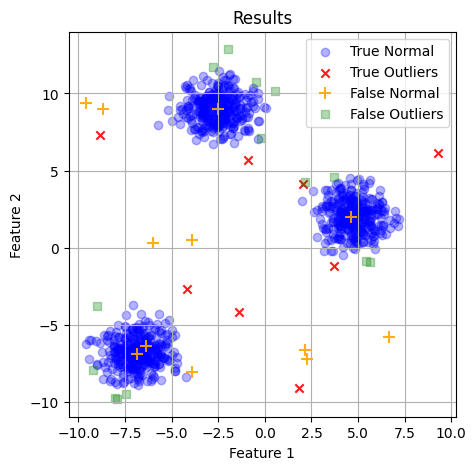

In [24]:
import optuna
from sklearn.metrics import f1_score

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    max_samples = trial.suggest_float('max_samples', 0.1, 1.0)
    max_features = trial.suggest_float('max_features', 0.1, 1.0)
    contamination = trial.suggest_float('contamination', 0.01, 0.5)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])

    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        bootstrap=bootstrap,
        random_state=random_state
    )
    model.fit(X)
    labels = model.predict(X)
    return f1_score(y, labels, pos_label=-1)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

def evaluate_trial(trial):
    best_params = trial.params
    model = IsolationForest(
        n_estimators=best_params['n_estimators'],
        max_samples=best_params['max_samples'],
        max_features=best_params['max_features'],
        contamination=best_params['contamination'],
        bootstrap=best_params['bootstrap'],
        random_state=random_state
    )
    model.fit(X)
    labels = model.predict(X)
    print(classification_report(y, labels))
    plot_results(X, y, labels)

evaluate_trial(study.best_trial)
plt.show()

[I 2025-11-13 00:40:35,047] A new study created in memory with name: no-name-3bb275b6-36ca-4164-9f5c-27df7404f2df
[I 2025-11-13 00:40:35,260] Trial 0 finished with value: 0.37735849056603776 and parameters: {'n_estimators': 87, 'max_samples': 0.7030914134658196, 'max_features': 0.23505066339795563, 'contamination': 0.08494717295979848, 'bootstrap': True}. Best is trial 0 with value: 0.37735849056603776.
[I 2025-11-13 00:40:35,483] Trial 1 finished with value: 0.2604166666666667 and parameters: {'n_estimators': 81, 'max_samples': 0.9559151677920523, 'max_features': 0.3733694354135235, 'contamination': 0.011746937497956213, 'bootstrap': False}. Best is trial 0 with value: 0.37735849056603776.
[I 2025-11-13 00:40:35,686] Trial 2 finished with value: 0.272108843537415 and parameters: {'n_estimators': 91, 'max_samples': 0.40494290476268546, 'max_features': 0.7521621438102021, 'contamination': 0.4080804146502941, 'bootstrap': False}. Best is trial 0 with value: 0.37735849056603776.
[I 2025-1

              precision    recall  f1-score   support

        -1.0       0.11      0.50      0.19        20
         1.0       0.99      0.92      0.95       980

    accuracy                           0.91      1000
   macro avg       0.55      0.71      0.57      1000
weighted avg       0.97      0.91      0.94      1000



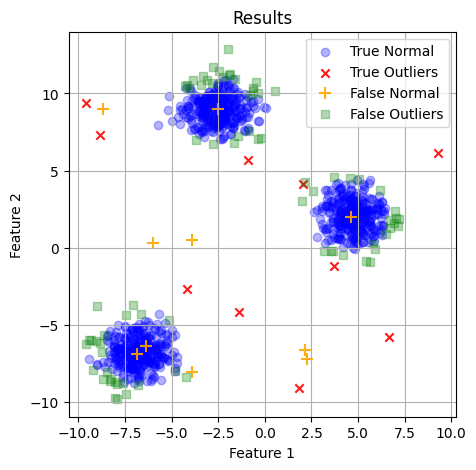

In [35]:
from sklearn.metrics import fbeta_score

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 100)
    max_samples = trial.suggest_float('max_samples', 0.1, 1.0)
    max_features = trial.suggest_float('max_features', 0.1, 1.0)
    contamination = trial.suggest_float('contamination', 0.01, 0.5)
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])

    model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        max_features=max_features,
        contamination=contamination,
        bootstrap=bootstrap,
        random_state=random_state
    )
    model.fit(X)
    labels = model.predict(X)
    return fbeta_score(y, labels, pos_label=-1, beta=3)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

evaluate_trial(study.best_trial)
plt.show()

              precision    recall  f1-score   support

        -1.0       0.30      0.80      0.43        20
         1.0       1.00      0.96      0.98       980

    accuracy                           0.96      1000
   macro avg       0.65      0.88      0.71      1000
weighted avg       0.98      0.96      0.97      1000



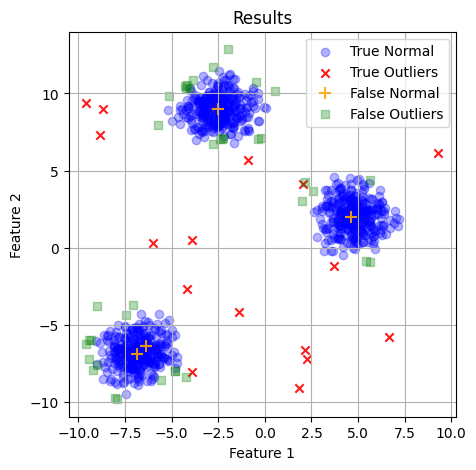

In [30]:
from sklearn.neighbors import LocalOutlierFactor

model = LocalOutlierFactor()

y_pred = model.fit_predict(X)
print(classification_report(y, y_pred))
plot_results(X, y, y_pred)
plt.show()

[I 2025-11-13 00:45:52,712] A new study created in memory with name: no-name-0f5f8155-a6a9-43c4-a911-aea6b209b3ca
[I 2025-11-13 00:45:52,726] Trial 0 finished with value: 0.10714285714285714 and parameters: {'n_neighbors': 3, 'algorithm': 'auto', 'leaf_size': 39, 'metric': 'minkowski', 'contamination': 0.20342914152551372}. Best is trial 0 with value: 0.10714285714285714.
[I 2025-11-13 00:45:52,739] Trial 1 finished with value: 0.5172413793103449 and parameters: {'n_neighbors': 6, 'algorithm': 'brute', 'leaf_size': 38, 'metric': 'minkowski', 'contamination': 0.037157151333450336}. Best is trial 1 with value: 0.5172413793103449.
[I 2025-11-13 00:45:52,751] Trial 2 finished with value: 0.064 and parameters: {'n_neighbors': 2, 'algorithm': 'brute', 'leaf_size': 14, 'metric': 'euclidean', 'contamination': 0.2293545551888159}. Best is trial 1 with value: 0.5172413793103449.
[I 2025-11-13 00:45:52,762] Trial 3 finished with value: 0.10526315789473684 and parameters: {'n_neighbors': 2, 'algor

              precision    recall  f1-score   support

        -1.0       1.00      0.60      0.75        20
         1.0       0.99      1.00      1.00       980

    accuracy                           0.99      1000
   macro avg       1.00      0.80      0.87      1000
weighted avg       0.99      0.99      0.99      1000



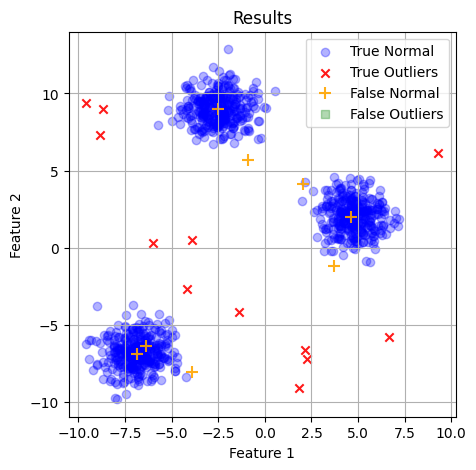

In [45]:
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 1, 10)
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])
    leaf_size = trial.suggest_int('leaf_size', 10, 50)
    metric = trial.suggest_categorical('metric', ['minkowski', 'euclidean', 'manhattan'])
    contamination = trial.suggest_float('contamination', 0.01, 0.5)

    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        algorithm=algorithm,
        leaf_size=leaf_size,
        metric=metric,
        contamination=contamination
    )

    labels = model.fit_predict(X)
    return fbeta_score(y, labels, pos_label=-1, beta=1)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

def evaluate_trial(trial):
    best_params = trial.params
    model = LocalOutlierFactor(
        n_neighbors=best_params['n_neighbors'],
        algorithm=best_params['algorithm'],
        leaf_size=best_params['leaf_size'],
        metric=best_params['metric'],
        contamination=best_params['contamination']
    )
    labels = model.fit_predict(X)
    print(classification_report(y, labels))
    plot_results(X, y, labels)

evaluate_trial(study.best_trial)
plt.show()

              precision    recall  f1-score   support

        -1.0       0.03      0.70      0.05        20
         1.0       0.99      0.51      0.67       980

    accuracy                           0.51      1000
   macro avg       0.51      0.60      0.36      1000
weighted avg       0.97      0.51      0.66      1000



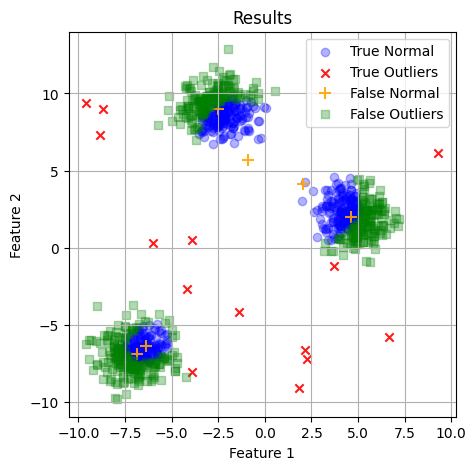

In [46]:
from sklearn.svm import OneClassSVM

model = OneClassSVM()
model.fit(X)

y_pred = model.predict(X)
print(classification_report(y, y_pred))
plot_results(X, y, y_pred)